**Konfigurasi Awal**

In [1]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed:", SEED)

Random Seed: 42


**Tahap 1** : EXPLORATORY DATA ANALYSIS (EDA) & DATA SPLITTING


Memuat dataset...
Jumlah data : 20,000 baris
Jumlah kolom: 2

Informasi Dataset:
- Dataset dibuat menggunakan Rule-Based Synthetic Generation
- Domain data berupa komentar tren fashion
- Terdiri dari tiga kelas sentimen:
  Positif, Netral, dan Negatif
- Mengandung variasi slang, typo, negasi, dan opini campuran

Cek Missing Values:
ulasan      0
sentimen    0

Contoh 5 Data Acak:
                                                             ulasan sentimen
10650  sejujurnya terlalu biasa tapi ternyata baguss juga menurutku  Positif
2041                 awalnya kurang yakin tapi ternyata kereen wkwk  Positif
8668           buat saya pribadi biasa aja tapi jadi suka menurutku  Positif
1114                                buat aku pribadi kurang menarik  Negatif
13902          modelnya lumayan tapi menurut saya kurang cocok wkwk  Negatif

Distribusi Sentimen:
sentimen
Negatif    7000
Positif    7000
Netral     6000

Jumlah Kalimat Unik:
8560

Kalimat Unik per Kelas:
sentimen
Negatif    288

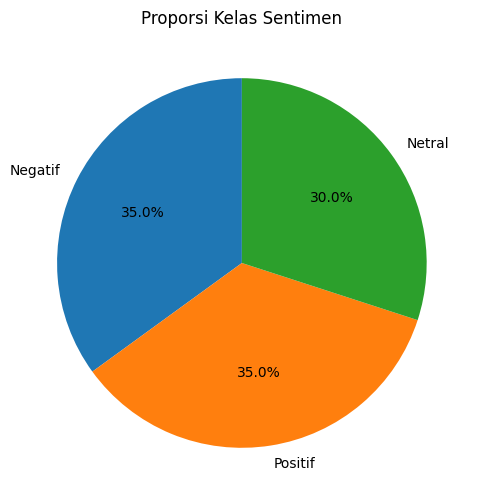

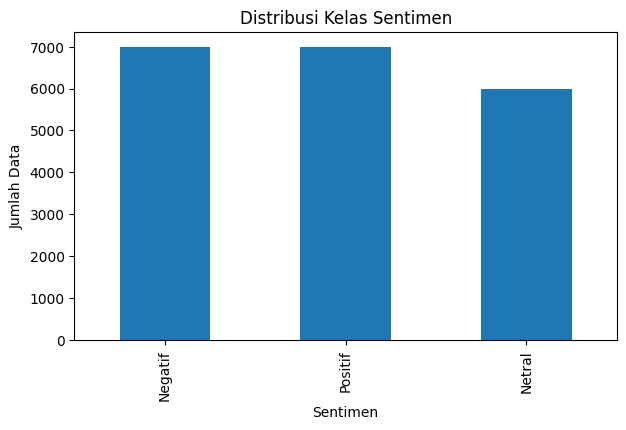


PROSES TRAIN TEST SPLIT

Jumlah Data Training:
16000

Jumlah Data Testing:
4000

Distribusi Kelas Data Training:
Negatif    5600
Positif    5600
Netral     4800

Distribusi Kelas Data Testing:
Negatif    1400
Positif    1400
Netral     1200

Tahap 1 selesai.
Dataset siap masuk ke tahap preprocessing teks.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#Load Dataset
print("\nMemuat dataset...")
df_fashion = pd.read_csv("dataset_trenfashion.csv")

print(f"Jumlah data : {len(df_fashion):,} baris")
print(f"Jumlah kolom: {df_fashion.shape[1]}")

#Informasi Dataset
print("\nInformasi Dataset:")
print("- Dataset dibuat menggunakan Rule-Based Synthetic Generation")
print("- Domain data berupa komentar tren fashion")
print("- Terdiri dari tiga kelas sentimen:")
print("  Positif, Netral, dan Negatif")
print("- Mengandung variasi slang, typo, negasi, dan opini campuran")

#Cek Data Kosong
print("\nCek Missing Values:")
print(df_fashion.isnull().sum().to_string())

#Contoh Data
pd.set_option('display.max_colwidth', None)

print("\nContoh 5 Data Acak:")
print(df_fashion.sample(5).to_string())

#Distribusi Kelas
distribusi = df_fashion["sentimen"].value_counts()

print("\nDistribusi Sentimen:")
print(distribusi.to_string())

#Analisis Variasi Dataset
print("\nJumlah Kalimat Unik:")
print(df_fashion["ulasan"].nunique())

print("\nKalimat Unik per Kelas:")
print(
df_fashion.groupby("sentimen")["ulasan"]
.nunique()
.to_string()
)

duplicate_rate = (
1 - df_fashion["ulasan"].nunique() / len(df_fashion)
) * 100

print(f"\nDuplicate Rate : {duplicate_rate:.2f}%")

#Visualisasi Distribusi Kelas
plt.figure(figsize=(6, 6))

plt.pie(
distribusi,
labels=distribusi.index,
autopct='%1.1f%%',
startangle=90
)

plt.title("Proporsi Kelas Sentimen")
plt.show()

#Bar Chart Distribusi Kelas
plt.figure(figsize=(7, 4))

distribusi.plot(kind="bar")

plt.title("Distribusi Kelas Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Data")

plt.show()

#Pembagian Data Training dan Data Testing
print("\n" + "=" * 70)
print("PROSES TRAIN TEST SPLIT")
print("=" * 70)

X = df_fashion["ulasan"].values
y = df_fashion["sentimen"].values

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

print("\nJumlah Data Training:")
print(len(X_train))

print("\nJumlah Data Testing:")
print(len(X_test))

print("\nDistribusi Kelas Data Training:")
print(
pd.Series(y_train)
.value_counts()
.to_string()
)

print("\nDistribusi Kelas Data Testing:")
print(
pd.Series(y_test)
.value_counts()
.to_string()
)

print("\nTahap 1 selesai.")
print("Dataset siap masuk ke tahap preprocessing teks.")


**TAHAP 2** : PREPROCESSING DAN TRANSFORMASI TEKS

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#Label Encoding
print("\n[1] Mengubah label sentimen menjadi representasi numerik")

le = LabelEncoder()

# fit hanya pada data training untuk menghindari data leakage

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Mapping Label:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

#TF-IDF untuk SVM dan Naive Bayes

print("\n[2] Membentuk fitur TF-IDF untuk Naive Bayes dan SVM")

# unigram + bigram
# membantu mengenali pola seperti:
# 'tidak suka', 'bukan selera', 'kurang menarik'
tfidf = TfidfVectorizer(
max_features=5000,
ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Bentuk Matriks TF-IDF:")
print(X_train_tfidf.shape)

print("\nJumlah Fitur TF-IDF:")
print(len(tfidf.get_feature_names_out()))

#Tokenizer untuk LSTM
print("\n[3] Membentuk Sequence untuk LSTM")

tokenizer = Tokenizer(
num_words=5000,
oov_token="<oov>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq_raw = tokenizer.texts_to_sequences(X_train)
X_test_seq_raw = tokenizer.texts_to_sequences(X_test)

# komentar tren fashion relatif pendek
# sehingga panjang maksimum 20 token sudah cukup
max_length = 20

X_train_seq = pad_sequences(
X_train_seq_raw,
maxlen=max_length,
padding='post',
truncating='post'
)

X_test_seq = pad_sequences(
X_test_seq_raw,
maxlen=max_length,
padding='post',
truncating='post'
)

# ukuran vocabulary aktual
vocab_size = len(tokenizer.word_index) + 1

print(f"Panjang Sequence : {max_length}")
print(f"Ukuran Vocabulary : {vocab_size}")

print("\nBentuk Data Sequence:")
print(X_train_seq.shape)

#Contoh Hasil Tokenisasi
print("\n[4] Contoh Tokenisasi")

contoh_teks = X_train[0]

print("Teks Asli:")
print(contoh_teks)

print("\nSequence:")
print(tokenizer.texts_to_sequences([contoh_teks])[0])

#Catatan Fairness Experience
print("\n[Catatan Fairness]")

print(
"TF-IDF dan Sequence dibangun dari sumber data training "
"dan testing yang sama sehingga perbandingan antar model "
"dilakukan secara adil."
)

print(
"Batas kosakata pada kedua pendekatan juga disamakan "
"sebanyak 5000 kata."
)

print("\nTahap 2 selesai.")
print("Data siap digunakan untuk eksperimen Naive Bayes, SVM, dan LSTM.")



[1] Mengubah label sentimen menjadi representasi numerik
Mapping Label:
{'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

[2] Membentuk fitur TF-IDF untuk Naive Bayes dan SVM
Bentuk Matriks TF-IDF:
(16000, 864)

Jumlah Fitur TF-IDF:
864

[3] Membentuk Sequence untuk LSTM
Panjang Sequence : 20
Ukuran Vocabulary : 113

Bentuk Data Sequence:
(16000, 20)

[4] Contoh Tokenisasi
Teks Asli:
menarikk sih tapi lumayan aja haha

Sequence:
[31, 7, 2, 28, 8, 15]

[Catatan Fairness]
TF-IDF dan Sequence dibangun dari sumber data training dan testing yang sama sehingga perbandingan antar model dilakukan secara adil.
Batas kosakata pada kedua pendekatan juga disamakan sebanyak 5000 kata.

Tahap 2 selesai.
Data siap digunakan untuk eksperimen Naive Bayes, SVM, dan LSTM.


**TAHAP 3** : NAIVE BAYES BASELINE


[1] Melatih Model Naive Bayes
Training selesai.

[2] Melakukan Prediksi

[3] Evaluasi Model
Accuracy  : 0.9435
Precision : 0.9435
Recall    : 0.9435
F1 Score  : 0.9435

Classification Report
              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00      1400
      Netral       0.91      0.90      0.91      1200
     Positif       0.91      0.93      0.92      1400

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000


[4] Menampilkan Confusion Matrix


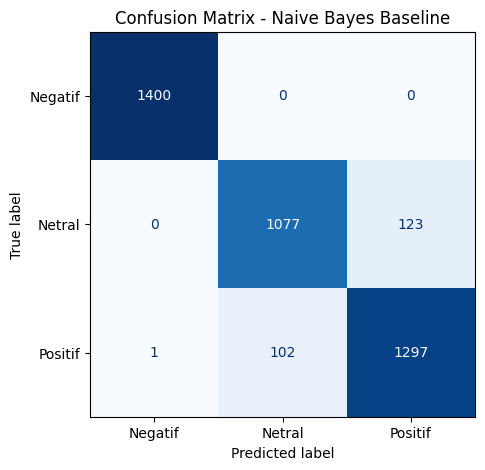


Tahap 3 selesai.
Naive Bayes berhasil dijadikan baseline awal.


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

#Training Model
print("\n[1] Melatih Model Naive Bayes")

# alpha=1.0 adalah konfigurasi standar
# digunakan sebagai baseline awal
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(
X_train_tfidf,
y_train_enc
)

print("Training selesai.")

#Prediksi
print("\n[2] Melakukan Prediksi")
y_pred_nb = nb_model.predict(X_test_tfidf)

#Evaluasi
print("\n[3] Evaluasi Model")
acc_nb = accuracy_score(y_test_enc, y_pred_nb)

precision_nb = precision_score(
y_test_enc,
y_pred_nb,
average='weighted'
)

recall_nb = recall_score(
y_test_enc,
y_pred_nb,
average='weighted'
)

f1_nb = f1_score(
y_test_enc,
y_pred_nb,
average='weighted'
)

print(f"Accuracy  : {acc_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1 Score  : {f1_nb:.4f}")

#Classification Report

print("\nClassification Report")

print(
classification_report(
y_test_enc,
y_pred_nb,
target_names=le.classes_
)
)

#Confusion Matrix
print("\n[4] Menampilkan Confusion Matrix")

cm_nb = confusion_matrix(
y_test_enc,
y_pred_nb
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
confusion_matrix=cm_nb,
display_labels=le.classes_
)

disp.plot(
cmap="Blues",
ax=ax,
colorbar=False
)

plt.title("Confusion Matrix - Naive Bayes Baseline")

plt.show()

#Ringkasan Hasil
hasil_nb = {
"Model": "Naive Bayes",
"Accuracy": acc_nb,
"Precision": precision_nb,
"Recall": recall_nb,
"F1 Score": f1_nb
}

print("\nTahap 3 selesai.")
print("Naive Bayes berhasil dijadikan baseline awal.")


**TAHAP 4** : SVM BASELINE


[1] Melatih Model SVM
Training selesai.

[2] Melakukan Prediksi

[3] Evaluasi Model
Accuracy  : 0.9495
Precision : 0.9500
Recall    : 0.9495
F1 Score  : 0.9494

Classification Report
              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00      1400
      Netral       0.94      0.89      0.91      1200
     Positif       0.91      0.95      0.93      1400

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


[4] Menampilkan Confusion Matrix


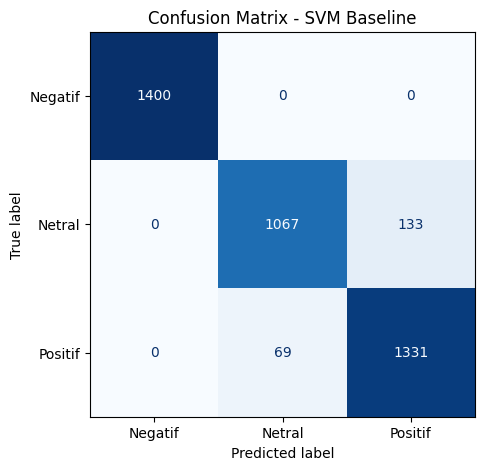


Tahap 4 selesai.
SVM berhasil dijadikan baseline pembanding.


In [5]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

#Training Model
print("\n[1] Melatih Model SVM")

# konfigurasi baseline
# belum dilakukan tuning hyperparameter
svm_model = LinearSVC(
C=1.0,
max_iter=10000,
random_state=42
)

svm_model.fit(
X_train_tfidf,
y_train_enc
)

print("Training selesai.")

#Prediksi
print("\n[2] Melakukan Prediksi")

y_pred_svm = svm_model.predict(X_test_tfidf)

#Evaluasi
print("\n[3] Evaluasi Model")

acc_svm = accuracy_score(
y_test_enc,
y_pred_svm
)

precision_svm = precision_score(
y_test_enc,
y_pred_svm,
average='weighted'
)

recall_svm = recall_score(
y_test_enc,
y_pred_svm,
average='weighted'
)

f1_svm = f1_score(
y_test_enc,
y_pred_svm,
average='weighted'
)

print(f"Accuracy  : {acc_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1 Score  : {f1_svm:.4f}")

#Classification Report
print("\nClassification Report")

print(
classification_report(
y_test_enc,
y_pred_svm,
target_names=le.classes_
)
)

#Confusion Matrix
print("\n[4] Menampilkan Confusion Matrix")

cm_svm = confusion_matrix(
y_test_enc,
y_pred_svm
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
confusion_matrix=cm_svm,
display_labels=le.classes_
)

disp.plot(
cmap="Blues",
ax=ax,
colorbar=False
)

plt.title("Confusion Matrix - SVM Baseline")

plt.show()

#Ringkasan Hasil
hasil_svm = {
"Model": "SVM",
"Accuracy": acc_svm,
"Precision": precision_svm,
"Recall": recall_svm,
"F1 Score": f1_svm
}

print("\nTahap 4 selesai.")
print("SVM berhasil dijadikan baseline pembanding.")


**TAHAP 5** : LSTM BASELINE


[1] Menyiapkan Label One-Hot
Shape y_train : (16000, 3)
Shape y_test  : (4000, 3)

[2] Membangun Arsitektur LSTM Baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


[3] Melatih Model LSTM
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8031 - loss: 0.4069 - val_accuracy: 0.9325 - val_loss: 0.1181
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9472 - loss: 0.0864 - val_accuracy: 0.9344 - val_loss: 0.0864
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9474 - loss: 0.0770 - val_accuracy: 0.9344 - val_loss: 0.0834
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9481 - loss: 0.0765 - val_accuracy: 0.9344 - val_loss: 0.0820
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9481 - loss: 0.0763 - val_accuracy: 0.9356 - val_loss: 0.0815
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9474 - loss: 0.0762 - val_accuracy: 0.9362 - val_loss: 0.0812
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9472 - loss: 0.0803 - val_accuracy: 0.9344 - val_loss: 0.0951
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9464 

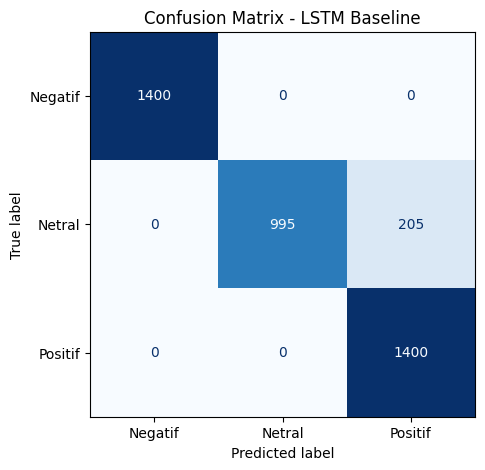

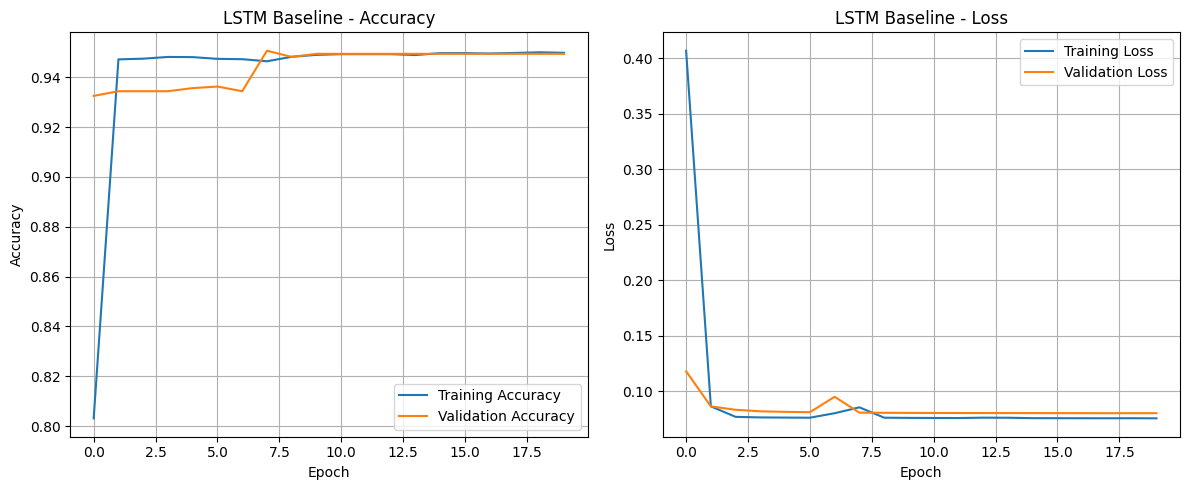


Tahap 5 selesai.
LSTM baseline berhasil dievaluasi.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np

#Persiapan Label
print("\n[1] Menyiapkan Label One-Hot")

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

print("Shape y_train :", y_train_cat.shape)
print("Shape y_test  :", y_test_cat.shape)

#Membangun Model
print("\n[2] Membangun Arsitektur LSTM Baseline")

lstm_baseline = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),

    LSTM(64),

    Dense(
        3,
        activation='softmax'
    )
])

lstm_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_baseline.summary()

#Training
print("\n[3] Melatih Model LSTM")

history_lstm = lstm_baseline.fit(
    X_train_seq,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

#Evaluasi
print("\n[4] Evaluasi Model")

y_pred_prob = lstm_baseline.predict(X_test_seq)

y_pred_lstm = np.argmax(
    y_pred_prob,
    axis=1
)

acc_lstm = accuracy_score(
    y_test_enc,
    y_pred_lstm
)

precision_lstm = precision_score(
    y_test_enc,
    y_pred_lstm,
    average='weighted'
)

recall_lstm = recall_score(
    y_test_enc,
    y_pred_lstm,
    average='weighted'
)

f1_lstm = f1_score(
    y_test_enc,
    y_pred_lstm,
    average='weighted'
)

print(f"Accuracy  : {acc_lstm:.4f}")
print(f"Precision : {precision_lstm:.4f}")
print(f"Recall    : {recall_lstm:.4f}")
print(f"F1 Score  : {f1_lstm:.4f}")

#classification Report
print("\nClassification Report")

print(
    classification_report(
        y_test_enc,
        y_pred_lstm,
        target_names=le.classes_
    )
)

#Confusion Matrix
print("\n[5] Menampilkan Confusion Matrix")

cm_lstm = confusion_matrix(
    y_test_enc,
    y_pred_lstm
)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - LSTM Baseline")

plt.show()

#Grafik Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

#Grafik Loss
plt.subplot(1,2,2)

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Ringkasan
hasil_lstm = {
    "Model": "LSTM Baseline",
    "Accuracy": acc_lstm,
    "Precision": precision_lstm,
    "Recall": recall_lstm,
    "F1 Score": f1_lstm
}

print("\nTahap 5 selesai.")
print("LSTM baseline berhasil dievaluasi.")

**TAHAP 6** : Naive Bayes + SMOTE


[1] Distribusi Data Training Sebelum SMOTE
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Melakukan SMOTE pada Data Training

[3] Distribusi Data Training Setelah SMOTE
0    5600
1    5600
2    5600
Name: count, dtype: int64

[4] Melatih Model Naive Bayes
Training selesai.

[5] Melakukan Prediksi

[6] Evaluasi Model
Accuracy  : 0.9405
Precision : 0.9406
Recall    : 0.9405
F1 Score  : 0.9405

Classification Report

              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00      1400
      Netral       0.90      0.91      0.90      1200
     Positif       0.92      0.91      0.91      1400

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000


[7] Menampilkan Confusion Matrix


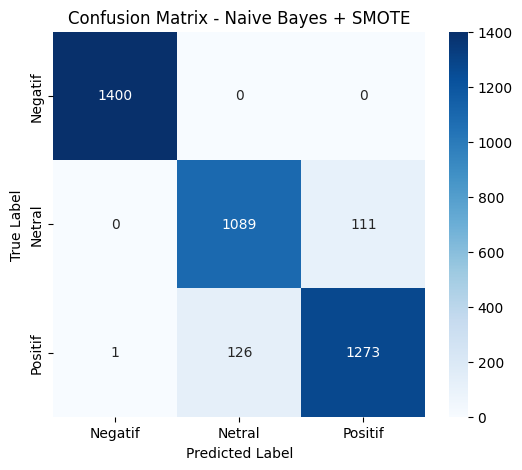


Tahap 6 selesai.
Eksperimen Naive Bayes + SMOTE berhasil dijalankan.


In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================================
# [1] Distribusi sebelum SMOTE
# ==========================================================

print("\n[1] Distribusi Data Training Sebelum SMOTE")

sebelum_smote = pd.Series(y_train_enc).value_counts().sort_index()

print(sebelum_smote)

# ==========================================================
# [2] SMOTE
# ==========================================================

print("\n[2] Melakukan SMOTE pada Data Training")

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train_enc
)

# ==========================================================
# [3] Distribusi setelah SMOTE
# ==========================================================

print("\n[3] Distribusi Data Training Setelah SMOTE")

sesudah_smote = pd.Series(y_train_smote).value_counts().sort_index()

print(sesudah_smote)

# ==========================================================
# [4] Training Naive Bayes
# ==========================================================

print("\n[4] Melatih Model Naive Bayes")

nb_smote = MultinomialNB()

nb_smote.fit(
    X_train_smote,
    y_train_smote
)

print("Training selesai.")

# ==========================================================
# [5] Prediksi
# ==========================================================

print("\n[5] Melakukan Prediksi")

y_pred_nb_smote = nb_smote.predict(X_test_tfidf)

# ==========================================================
# [6] Evaluasi
# ==========================================================

print("\n[6] Evaluasi Model")

acc = accuracy_score(y_test_enc, y_pred_nb_smote)
prec = precision_score(
    y_test_enc,
    y_pred_nb_smote,
    average='weighted'
)
rec = recall_score(
    y_test_enc,
    y_pred_nb_smote,
    average='weighted'
)
f1 = f1_score(
    y_test_enc,
    y_pred_nb_smote,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred_nb_smote,
        target_names=le.classes_
    )
)

# ==========================================================
# [7] Confusion Matrix
# ==========================================================

print("\n[7] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred_nb_smote
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - Naive Bayes + SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nTahap 6 selesai.")
print("Eksperimen Naive Bayes + SMOTE berhasil dijalankan.")

**TAHAP 7** : SVM + SMOTE


[1] Distribusi Data Training Sebelum SMOTE
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Melakukan SMOTE pada Data Training

[3] Distribusi Data Training Setelah SMOTE
0    5600
1    5600
2    5600
Name: count, dtype: int64

[4] Melatih Model SVM
Training selesai.

[5] Melakukan Prediksi

[6] Evaluasi Model
Accuracy  : 0.9475
Precision : 0.9475
Recall    : 0.9475
F1 Score  : 0.9475

Classification Report

              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00      1400
      Netral       0.92      0.90      0.91      1200
     Positif       0.92      0.94      0.93      1400

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


[7] Menampilkan Confusion Matrix


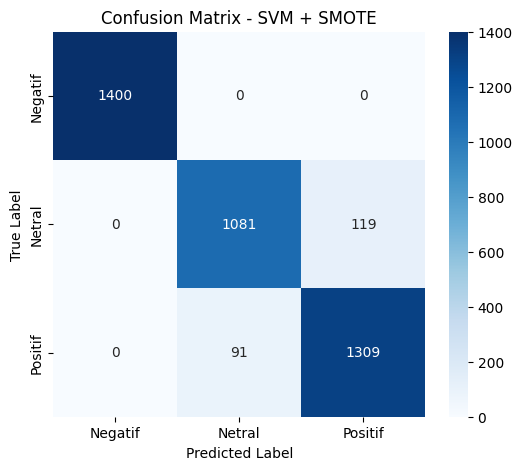


Tahap 7 selesai.
Eksperimen SVM + SMOTE berhasil dijalankan.


In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================================
# [1] Distribusi sebelum SMOTE
# ==========================================================

print("\n[1] Distribusi Data Training Sebelum SMOTE")

sebelum_smote = pd.Series(y_train_enc).value_counts().sort_index()

print(sebelum_smote)

# ==========================================================
# [2] SMOTE
# ==========================================================

print("\n[2] Melakukan SMOTE pada Data Training")

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train_enc
)

# ==========================================================
# [3] Distribusi setelah SMOTE
# ==========================================================

print("\n[3] Distribusi Data Training Setelah SMOTE")

sesudah_smote = pd.Series(y_train_smote).value_counts().sort_index()

print(sesudah_smote)

# ==========================================================
# [4] Training SVM
# ==========================================================

print("\n[4] Melatih Model SVM")

svm_smote = LinearSVC(
    random_state=42,
    max_iter=10000
)

svm_smote.fit(
    X_train_smote,
    y_train_smote
)

print("Training selesai.")

# ==========================================================
# [5] Prediksi
# ==========================================================

print("\n[5] Melakukan Prediksi")

y_pred_svm_smote = svm_smote.predict(X_test_tfidf)

# ==========================================================
# [6] Evaluasi
# ==========================================================

print("\n[6] Evaluasi Model")

acc = accuracy_score(y_test_enc, y_pred_svm_smote)

prec = precision_score(
    y_test_enc,
    y_pred_svm_smote,
    average='weighted'
)

rec = recall_score(
    y_test_enc,
    y_pred_svm_smote,
    average='weighted'
)

f1 = f1_score(
    y_test_enc,
    y_pred_svm_smote,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred_svm_smote,
        target_names=le.classes_
    )
)

# ==========================================================
# [7] Confusion Matrix
# ==========================================================

print("\n[7] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred_svm_smote
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - SVM + SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nTahap 7 selesai.")
print("Eksperimen SVM + SMOTE berhasil dijalankan.")

**TAHAP 8** : LSTM + SMOTE


[1] Distribusi Data Training Sebelum SMOTE
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Melakukan SMOTE

Distribusi Setelah SMOTE
0    5600
1    5600
2    5600
Name: count, dtype: int64

[3] Menyiapkan Label One-Hot
Shape X_train : (16800, 20)
Shape y_train : (16800, 3)

[4] Membangun Model LSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


[5] Melatih Model
Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8349 - loss: 0.3390 - val_accuracy: 0.8732 - val_loss: 0.3200
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9403 - loss: 0.1012 - val_accuracy: 0.8839 - val_loss: 0.2733
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9464 - loss: 0.0820 - val_accuracy: 0.8708 - val_loss: 0.2968
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9486 - loss: 0.0778 - val_accuracy: 0.8601 - val_loss: 0.3120
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9497 - loss: 0.0765 - val_accuracy: 0.8667 - val_loss: 0.3315
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9492 - loss: 0.0779 - val_accuracy: 0.8560 - val_loss: 0.3648
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9474 - loss: 0.0871 - val_accuracy: 0.8679 - val_loss: 0.2493
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9503 - loss

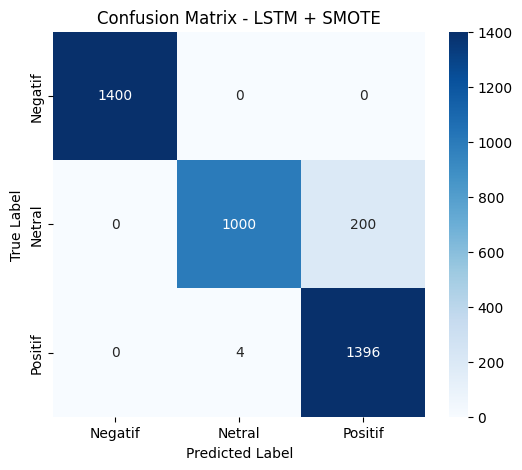

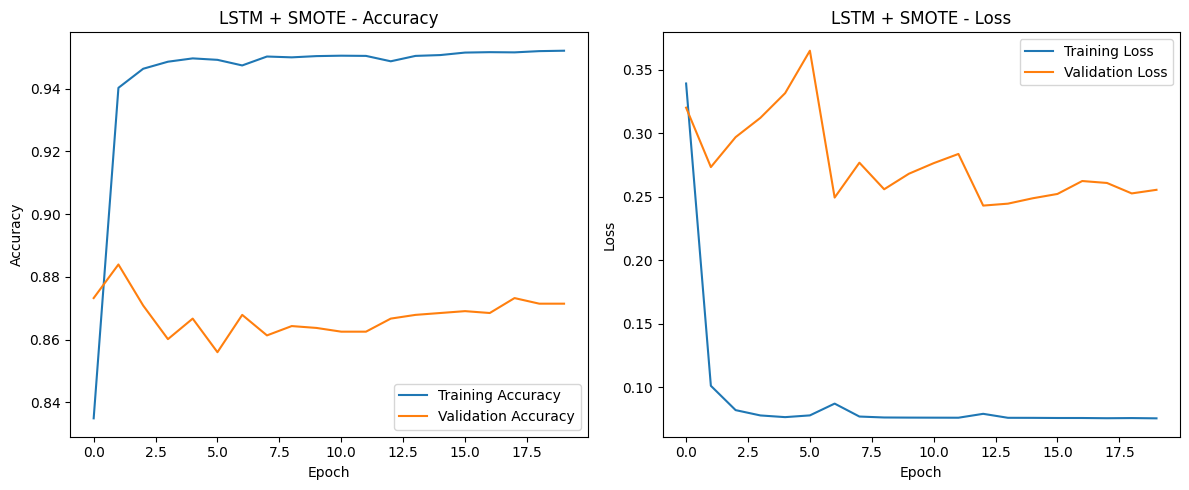


Tahap 8 selesai.
Eksperimen LSTM + SMOTE berhasil dijalankan.


In [9]:
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# [1] Distribusi sebelum SMOTE
# ==========================================================

print("\n[1] Distribusi Data Training Sebelum SMOTE")

print(
    pd.Series(y_train_enc)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [2] SMOTE pada sequence
# ==========================================================

print("\n[2] Melakukan SMOTE")

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_seq_smote, y_train_smote = smote.fit_resample(
    X_train_seq,
    y_train_enc
)

print("\nDistribusi Setelah SMOTE")

print(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [3] One-Hot Encoding
# ==========================================================

print("\n[3] Menyiapkan Label One-Hot")

y_train_smote_cat = to_categorical(y_train_smote)

y_test_cat = to_categorical(y_test_enc)

print("Shape X_train :", X_train_seq_smote.shape)
print("Shape y_train :", y_train_smote_cat.shape)

# ==========================================================
# [4] Arsitektur LSTM
# ==========================================================

print("\n[4] Membangun Model LSTM")

lstm_smote = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(64),

    Dense(
        3,
        activation='softmax'
    )
])

lstm_smote.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_smote.summary()

# ==========================================================
# [5] Training
# ==========================================================

print("\n[5] Melatih Model")

history_smote = lstm_smote.fit(
    X_train_seq_smote,
    y_train_smote_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ==========================================================
# [6] Prediksi
# ==========================================================

print("\n[6] Melakukan Prediksi")

y_pred_prob = lstm_smote.predict(
    X_test_seq
)

y_pred = y_pred_prob.argmax(axis=1)

# ==========================================================
# [7] Evaluasi
# ==========================================================

print("\n[7] Evaluasi Model")

acc = accuracy_score(
    y_test_enc,
    y_pred
)

prec = precision_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred,
        target_names=le.classes_
    )
)

# ==========================================================
# [8] Confusion Matrix
# ==========================================================

print("\n[8] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - LSTM + SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================================
# [9] Grafik Training
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history_smote.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_smote.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM + SMOTE - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history_smote.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_smote.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM + SMOTE - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("\nTahap 8 selesai.")
print("Eksperimen LSTM + SMOTE berhasil dijalankan.")

**TAHAP 9** : SVM + Class Weight


[1] Distribusi Data Training
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Melatih SVM dengan Class Weight
Training selesai.

[3] Melakukan Prediksi

[4] Evaluasi Model
Accuracy  : 0.9480
Precision : 0.9483
Recall    : 0.9480
F1 Score  : 0.9479

Classification Report

              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00      1400
      Netral       0.93      0.89      0.91      1200
     Positif       0.91      0.94      0.93      1400

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


[6] Menampilkan Confusion Matrix


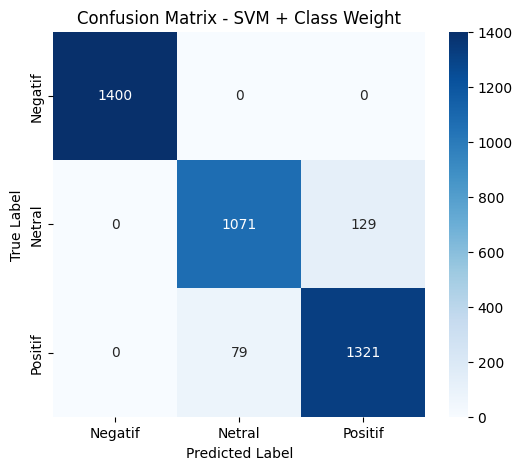


Tahap 9 selesai.
Eksperimen SVM + Class Weight berhasil dijalankan.


In [10]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================================
# [1] Distribusi Data Training
# ==========================================================

print("\n[1] Distribusi Data Training")

distribusi_train = (
    pd.Series(y_train_enc)
    .value_counts()
    .sort_index()
)

print(distribusi_train)

# ==========================================================
# [2] Training SVM + Class Weight
# ==========================================================

print("\n[2] Melatih SVM dengan Class Weight")

svm_cw = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=10000
)

svm_cw.fit(
    X_train_tfidf,
    y_train_enc
)

print("Training selesai.")

# ==========================================================
# [3] Prediksi
# ==========================================================

print("\n[3] Melakukan Prediksi")

y_pred_svm_cw = svm_cw.predict(
    X_test_tfidf
)

# ==========================================================
# [4] Evaluasi
# ==========================================================

print("\n[4] Evaluasi Model")

acc = accuracy_score(
    y_test_enc,
    y_pred_svm_cw
)

prec = precision_score(
    y_test_enc,
    y_pred_svm_cw,
    average='weighted'
)

rec = recall_score(
    y_test_enc,
    y_pred_svm_cw,
    average='weighted'
)

f1 = f1_score(
    y_test_enc,
    y_pred_svm_cw,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ==========================================================
# [5] Classification Report
# ==========================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred_svm_cw,
        target_names=le.classes_
    )
)

# ==========================================================
# [6] Confusion Matrix
# ==========================================================

print("\n[6] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred_svm_cw
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - SVM + Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nTahap 9 selesai.")
print("Eksperimen SVM + Class Weight berhasil dijalankan.")

TAHAP 10 : LSTM + Class Weight


[1] Distribusi Data Training
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Menghitung Class Weight
Class Weight:
{np.int64(0): np.float64(0.9523809523809523), np.int64(1): np.float64(1.1111111111111112), np.int64(2): np.float64(0.9523809523809523)}

[3] Menyiapkan Label

[4] Membangun Model LSTM


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


[5] Melatih Model
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8171 - loss: 0.3926 - val_accuracy: 0.9450 - val_loss: 0.1120
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9472 - loss: 0.0873 - val_accuracy: 0.9344 - val_loss: 0.0871
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9456 - loss: 0.0791 - val_accuracy: 0.9344 - val_loss: 0.0833
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9464 - loss: 0.0788 - val_accuracy: 0.9344 - val_loss: 0.0826
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9449 - loss: 0.0786 - val_accuracy: 0.9344 - val_loss: 0.0823
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9448 - loss: 0.0785 - val_accuracy: 0.9344 - val_loss: 0.0822
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9451 - loss: 0.0783 - val_accuracy: 0.9344 - val_loss: 0.0820
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9364 - lo

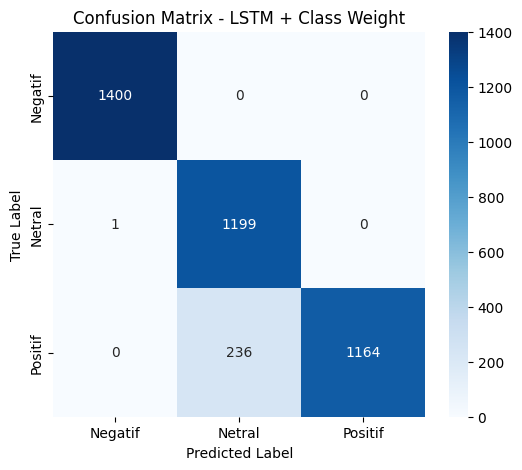

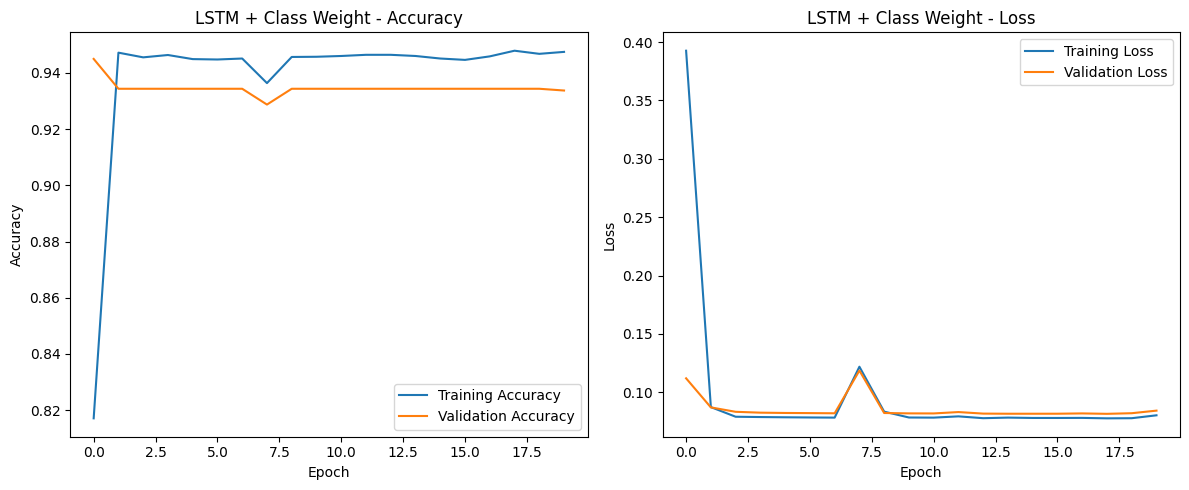


Tahap 10 selesai.
Eksperimen LSTM + Class Weight berhasil dijalankan.


In [11]:
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# [1] Distribusi Data Training
# ==========================================================

print("\n[1] Distribusi Data Training")

print(
    pd.Series(y_train_enc)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [2] Hitung Class Weight
# ==========================================================

print("\n[2] Menghitung Class Weight")

classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))

print("Class Weight:")
print(class_weights)

# ==========================================================
# [3] One-Hot Encoding
# ==========================================================

print("\n[3] Menyiapkan Label")

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

# ==========================================================
# [4] Membangun Model
# ==========================================================

print("\n[4] Membangun Model LSTM")

lstm_cw = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(64),

    Dense(
        3,
        activation='softmax'
    )
])

lstm_cw.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_cw.summary()

# ==========================================================
# [5] Training
# ==========================================================

print("\n[5] Melatih Model")

history_cw = lstm_cw.fit(
    X_train_seq,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# ==========================================================
# [6] Prediksi
# ==========================================================

print("\n[6] Melakukan Prediksi")

y_pred_prob = lstm_cw.predict(
    X_test_seq
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

# ==========================================================
# [7] Evaluasi
# ==========================================================

print("\n[7] Evaluasi Model")

acc = accuracy_score(
    y_test_enc,
    y_pred
)

prec = precision_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred,
        target_names=le.classes_
    )
)

# ==========================================================
# [8] Confusion Matrix
# ==========================================================

print("\n[8] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - LSTM + Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================================
# [9] Grafik Training
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history_cw.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cw.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM + Class Weight - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history_cw.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cw.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM + Class Weight - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("\nTahap 10 selesai.")
print("Eksperimen LSTM + Class Weight berhasil dijalankan.")

**TAHAP 11** : SVM + SMOTE + Class Weight


[1] Distribusi Data Training Sebelum SMOTE
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Melakukan SMOTE

Distribusi Setelah SMOTE
0    5600
1    5600
2    5600
Name: count, dtype: int64

[3] Melatih SVM + SMOTE + Class Weight
Training selesai.

[4] Melakukan Prediksi

[5] Evaluasi Model
Accuracy  : 0.9475
Precision : 0.9475
Recall    : 0.9475
F1 Score  : 0.9475

Classification Report

              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00      1400
      Netral       0.92      0.90      0.91      1200
     Positif       0.92      0.94      0.93      1400

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


[7] Menampilkan Confusion Matrix


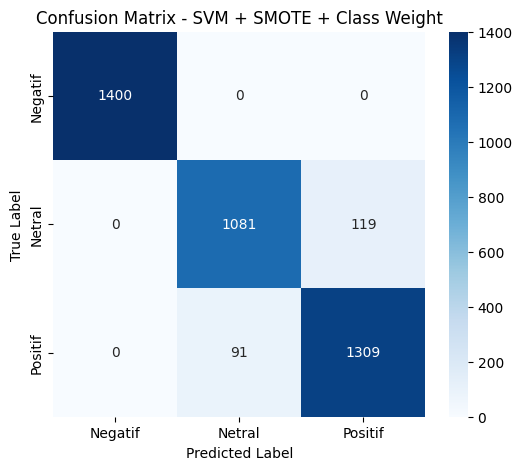


Tahap 11 selesai.
Eksperimen SVM + SMOTE + Class Weight berhasil dijalankan.


In [12]:
from imblearn.over_sampling import SMOTE

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# [1] Distribusi Sebelum SMOTE
# ==========================================================

print("\n[1] Distribusi Data Training Sebelum SMOTE")

print(
    pd.Series(y_train_enc)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [2] SMOTE
# ==========================================================

print("\n[2] Melakukan SMOTE")

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_tfidf_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train_enc
)

print("\nDistribusi Setelah SMOTE")

print(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [3] Training SVM
# ==========================================================

print("\n[3] Melatih SVM + SMOTE + Class Weight")

svm_smote_cw = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=10000
)

svm_smote_cw.fit(
    X_train_tfidf_smote,
    y_train_smote
)

print("Training selesai.")

# ==========================================================
# [4] Prediksi
# ==========================================================

print("\n[4] Melakukan Prediksi")

y_pred_svm_smote_cw = svm_smote_cw.predict(
    X_test_tfidf
)

# ==========================================================
# [5] Evaluasi
# ==========================================================

print("\n[5] Evaluasi Model")

acc = accuracy_score(
    y_test_enc,
    y_pred_svm_smote_cw
)

prec = precision_score(
    y_test_enc,
    y_pred_svm_smote_cw,
    average='weighted'
)

rec = recall_score(
    y_test_enc,
    y_pred_svm_smote_cw,
    average='weighted'
)

f1 = f1_score(
    y_test_enc,
    y_pred_svm_smote_cw,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ==========================================================
# [6] Classification Report
# ==========================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred_svm_smote_cw,
        target_names=le.classes_
    )
)

# ==========================================================
# [7] Confusion Matrix
# ==========================================================

print("\n[7] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred_svm_smote_cw
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - SVM + SMOTE + Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nTahap 11 selesai.")
print("Eksperimen SVM + SMOTE + Class Weight berhasil dijalankan.")

**TAHAP 12** : LSTM + SMOTE + Class Weight


[1] Distribusi Data Training Sebelum SMOTE
0    5600
1    4800
2    5600
Name: count, dtype: int64

[2] Melakukan SMOTE

Distribusi Setelah SMOTE
0    5600
1    5600
2    5600
Name: count, dtype: int64

[3] Menghitung Class Weight
{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}

[4] Menyiapkan Label

[5] Membangun Model LSTM


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


[6] Melatih Model
Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8253 - loss: 0.3536 - val_accuracy: 0.9345 - val_loss: 0.1896
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9411 - loss: 0.0968 - val_accuracy: 0.8768 - val_loss: 0.1936
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9506 - loss: 0.0770 - val_accuracy: 0.8744 - val_loss: 0.2133
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9510 - loss: 0.0765 - val_accuracy: 0.8744 - val_loss: 0.2249
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9490 - loss: 0.0852 - val_accuracy: 0.8732 - val_loss: 0.2504
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9507 - loss: 0.0763 - val_accuracy: 0.8696 - val_loss: 0.2562
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9507 - loss: 0.0761 - val_accuracy: 0.8690 - val_loss: 0.2614
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9507 - los

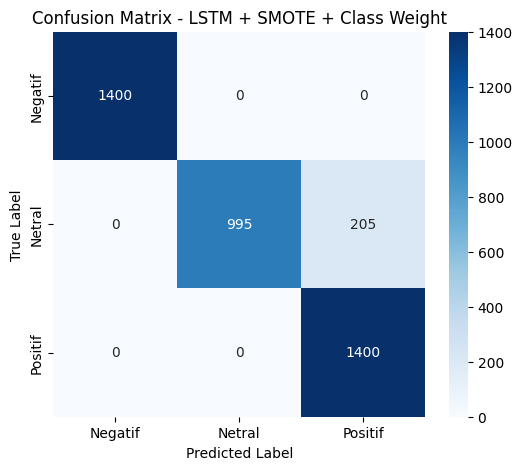

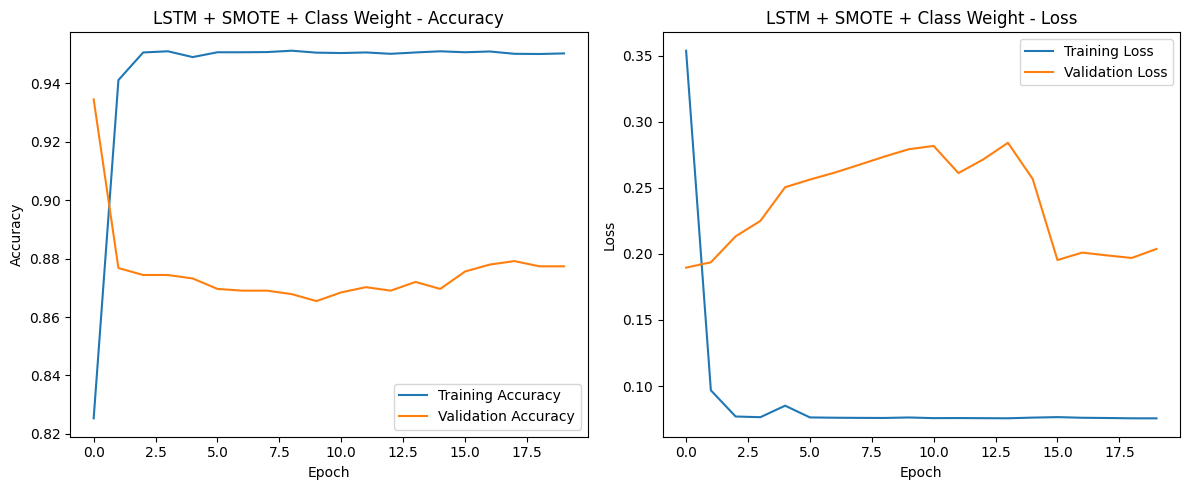


Tahap 12 selesai.
Eksperimen LSTM + SMOTE + Class Weight berhasil dijalankan.


In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# [1] Distribusi Sebelum SMOTE
# ==========================================================

print("\n[1] Distribusi Data Training Sebelum SMOTE")

print(
    pd.Series(y_train_enc)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [2] SMOTE
# ==========================================================

print("\n[2] Melakukan SMOTE")

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_seq_smote, y_train_smote = smote.fit_resample(
    X_train_seq,
    y_train_enc
)

print("\nDistribusi Setelah SMOTE")

print(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

# ==========================================================
# [3] Hitung Class Weight
# ==========================================================

print("\n[3] Menghitung Class Weight")

classes = np.unique(y_train_smote)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_smote
)

class_weights = dict(zip(classes, weights))

print(class_weights)

# ==========================================================
# [4] One Hot Encoding
# ==========================================================

print("\n[4] Menyiapkan Label")

y_train_smote_cat = to_categorical(y_train_smote)
y_test_cat = to_categorical(y_test_enc)

# ==========================================================
# [5] Model LSTM
# ==========================================================

print("\n[5] Membangun Model LSTM")

lstm_smote_cw = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(64),

    Dense(
        3,
        activation='softmax'
    )
])

lstm_smote_cw.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_smote_cw.summary()

# ==========================================================
# [6] Training
# ==========================================================

print("\n[6] Melatih Model")

history_smote_cw = lstm_smote_cw.fit(
    X_train_seq_smote,
    y_train_smote_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# ==========================================================
# [7] Prediksi
# ==========================================================

print("\n[7] Melakukan Prediksi")

y_pred_prob = lstm_smote_cw.predict(
    X_test_seq
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

# ==========================================================
# [8] Evaluasi
# ==========================================================

print("\n[8] Evaluasi Model")

acc = accuracy_score(
    y_test_enc,
    y_pred
)

prec = precision_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_enc,
    y_pred,
    average='weighted'
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_enc,
        y_pred,
        target_names=le.classes_
    )
)

# ==========================================================
# [9] Confusion Matrix
# ==========================================================

print("\n[9] Menampilkan Confusion Matrix")

cm = confusion_matrix(
    y_test_enc,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - LSTM + SMOTE + Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================================
# [10] Grafik Training
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history_smote_cw.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_smote_cw.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM + SMOTE + Class Weight - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history_smote_cw.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_smote_cw.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM + SMOTE + Class Weight - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("\nTahap 12 selesai.")
print("Eksperimen LSTM + SMOTE + Class Weight berhasil dijalankan.")

**TAHAP 13** : REKAPITULASI HASIL EKSPERIMEN

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np

hasil = []

# ==========================================================
# FUNGSI BANTU
# ==========================================================

def tambah_hasil(nama_model, y_true, y_pred):

    hasil.append({
        "Model": nama_model,
        "Accuracy": round(
            accuracy_score(y_true, y_pred), 4
        ),
        "Precision": round(
            precision_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            4
        ),
        "Recall": round(
            recall_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            4
        ),
        "F1-Score": round(
            f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            4
        )
    })

# ==========================================================
# BASELINE
# ==========================================================

print("\nMengumpulkan hasil baseline...")

tambah_hasil(
    "NB Baseline",
    y_test_enc,
    nb_model.predict(X_test_tfidf)
)

tambah_hasil(
    "SVM Baseline",
    y_test_enc,
    svm_model.predict(X_test_tfidf)
)

y_pred_lstm_base = np.argmax(
    lstm_baseline.predict(
        X_test_seq,
        verbose=0
    ),
    axis=1
)

tambah_hasil(
    "LSTM Baseline",
    y_test_enc,
    y_pred_lstm_base
)

# ==========================================================
# SMOTE
# ==========================================================

print("Mengumpulkan hasil SMOTE...")

tambah_hasil(
    "NB + SMOTE",
    y_test_enc,
    nb_smote.predict(X_test_tfidf)
)

tambah_hasil(
    "SVM + SMOTE",
    y_test_enc,
    svm_smote.predict(X_test_tfidf)
)

y_pred_lstm_smote = np.argmax(
    lstm_smote.predict(
        X_test_seq,
        verbose=0
    ),
    axis=1
)

tambah_hasil(
    "LSTM + SMOTE",
    y_test_enc,
    y_pred_lstm_smote
)

# ==========================================================
# CLASS WEIGHT
# ==========================================================

print("Mengumpulkan hasil Class Weight...")

tambah_hasil(
    "SVM + CW",
    y_test_enc,
    svm_cw.predict(X_test_tfidf)
)

y_pred_lstm_cw = np.argmax(
    lstm_cw.predict(
        X_test_seq,
        verbose=0
    ),
    axis=1
)

tambah_hasil(
    "LSTM + CW",
    y_test_enc,
    y_pred_lstm_cw
)

# ==========================================================
# SMOTE + CLASS WEIGHT
# ==========================================================

print("Mengumpulkan hasil SMOTE + CW...")

tambah_hasil(
    "SVM + SMOTE + CW",
    y_test_enc,
    svm_smote_cw.predict(X_test_tfidf)
)

y_pred_lstm_smote_cw = np.argmax(
    lstm_smote_cw.predict(
        X_test_seq,
        verbose=0
    ),
    axis=1
)

tambah_hasil(
    "LSTM + SMOTE + CW",
    y_test_enc,
    y_pred_lstm_smote_cw
)

# ==========================================================
# DATAFRAME HASIL
# ==========================================================

df_hasil = pd.DataFrame(hasil)

df_hasil = df_hasil.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*70)
print("RANKING SELURUH EKSPERIMEN")
print("="*70)

display(df_hasil)

# ==========================================================
# MODEL TERBAIK
# ==========================================================

print("\n")
print("="*70)

terbaik = df_hasil.iloc[0]

print("MODEL TERBAIK")
print("="*70)

print(f"Model     : {terbaik['Model']}")
print(f"Accuracy  : {terbaik['Accuracy']:.4f}")
print(f"Precision : {terbaik['Precision']:.4f}")
print(f"Recall    : {terbaik['Recall']:.4f}")
print(f"F1-Score  : {terbaik['F1-Score']:.4f}")

# ==========================================================
# SIMPAN KE CSV
# ==========================================================

df_hasil.to_csv(
    "rekap_hasil_eksperimen.csv",
    index=False
)

print("\nFile berhasil disimpan:")
print("rekap_hasil_eksperimen.csv")

print("\nTahap 13 selesai.")


Mengumpulkan hasil baseline...
Mengumpulkan hasil SMOTE...
Mengumpulkan hasil Class Weight...
Mengumpulkan hasil SMOTE + CW...


RANKING SELURUH EKSPERIMEN


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Baseline,0.9495,0.9500,0.9495,0.9494
1,LSTM + SMOTE,0.9490,0.9549,0.9490,0.9484
2,LSTM + SMOTE + CW,0.9487,0.9553,0.9487,0.9481
3,LSTM Baseline,0.9487,0.9553,0.9487,0.9481
4,SVM + CW,0.9480,0.9483,0.9480,0.9479
5,SVM + SMOTE + CW,0.9475,0.9475,0.9475,0.9475
6,SVM + SMOTE,0.9475,0.9475,0.9475,0.9475
7,NB Baseline,0.9435,0.9435,0.9435,0.9435
8,LSTM + CW,0.9407,0.9504,0.9407,0.9407
9,NB + SMOTE,0.9405,0.9406,0.9405,0.9405




MODEL TERBAIK
Model     : SVM Baseline
Accuracy  : 0.9495
Precision : 0.9500
Recall    : 0.9495
F1-Score  : 0.9494

File berhasil disimpan:
rekap_hasil_eksperimen.csv

Tahap 13 selesai.


**Tahap 14** : Analisis Kualitatif (Adversarial Test)

In [19]:
import pandas as pd
import numpy as np

print("="*70)
print("TAHAP 14 : ANALISIS KUALITATIF MODEL")
print("="*70)

print("""
Tujuan:
Menguji kemampuan model dalam memahami:

1. Negasi
2. Opini campuran
3. Kalimat berbalik
4. Slang words
5. Kalimat ambigu
""")

# ==========================================================
# DATA UJI KHUSUS
# ==========================================================

kalimat_uji = [

    # Negasi positif
    "bahan tidak panas dan sangat nyaman",

    # Negasi negatif
    "tidak bagus sama sekali jahitannya berantakan",

    # Opini campuran positif
    "awalnya saya ragu tapi ternyata bagus banget",

    # Opini campuran negatif
    "awalnya suka tapi setelah dipakai kecewa",

    # Slang positif
    "cakep parah sih outfitnya",

    # Slang negatif
    "zonk banget ternyata",

    # Ambigu netral
    "lumayan aja menurut saya",

    # Ambigu netral
    "biasa aja tidak ada yang spesial",

    # Positif panjang
    "kombinasi warnanya bagus modelnya modern dan nyaman dipakai",

    # Negatif panjang
    "warnanya kusam modelnya membosankan dan kualitasnya kurang baik"
]

label_asli = [
    "Positif",
    "Negatif",
    "Positif",
    "Negatif",
    "Positif",
    "Negatif",
    "Netral",
    "Netral",
    "Positif",
    "Negatif"
]

# ==========================================================
# TRANSFORMASI DATA
# ==========================================================

X_tfidf_uji = tfidf.transform(kalimat_uji)

X_seq_uji = pad_sequences(
    tokenizer.texts_to_sequences(kalimat_uji),
    maxlen=max_length
)

# ==========================================================
# NB
# ==========================================================

pred_nb_num = nb_model.predict(X_tfidf_uji)

pred_nb = le.inverse_transform(
    pred_nb_num
)

# ==========================================================
# SVM
# ==========================================================

pred_svm_num = svm_model.predict(
    X_tfidf_uji
)

pred_svm = le.inverse_transform(
    pred_svm_num
)

# ==========================================================
# LSTM TERBAIK
# ==========================================================

pred_lstm_num = np.argmax(
    lstm_smote.predict(
        X_seq_uji,
        verbose=0
    ),
    axis=1
)

pred_lstm = le.inverse_transform(
    pred_lstm_num
)

# ==========================================================
# TABEL HASIL
# ==========================================================

hasil_uji = pd.DataFrame({

    "Kalimat Uji": kalimat_uji,
    "Label Aktual": label_asli,

    "Prediksi NB": pred_nb,
    "Prediksi SVM": pred_svm,
    "Prediksi LSTM": pred_lstm

})

pd.set_option(
    "display.max_colwidth",
    None
)

print("\nHASIL PENGUJIAN KUALITATIF\n")

display(hasil_uji)

# ==========================================================
# HITUNG SKOR BENAR
# ==========================================================

benar_nb = (
    hasil_uji["Label Aktual"]
    ==
    hasil_uji["Prediksi NB"]
).sum()

benar_svm = (
    hasil_uji["Label Aktual"]
    ==
    hasil_uji["Prediksi SVM"]
).sum()

benar_lstm = (
    hasil_uji["Label Aktual"]
    ==
    hasil_uji["Prediksi LSTM"]
).sum()

# ==========================================================
# RINGKASAN
# ==========================================================

print("\n")
print("="*70)
print("REKAP HASIL")
print("="*70)

print(f"NB    : {benar_nb}/10")
print(f"SVM   : {benar_svm}/10")
print(f"LSTM  : {benar_lstm}/10")

# ==========================================================
# MODEL TERBAIK
# ==========================================================

skor = {
    "NB": benar_nb,
    "SVM": benar_svm,
    "LSTM": benar_lstm
}

terbaik = max(
    skor,
    key=skor.get
)

print("\nModel terbaik pada adversarial test:")
print(f"{terbaik} ({skor[terbaik]}/10)")

print("\nTahap 14 selesai.")

TAHAP 14 : ANALISIS KUALITATIF MODEL

Tujuan:
Menguji kemampuan model dalam memahami:

1. Negasi
2. Opini campuran
3. Kalimat berbalik
4. Slang words
5. Kalimat ambigu


HASIL PENGUJIAN KUALITATIF



,Kalimat Uji,Label Aktual,Prediksi NB,Prediksi SVM,Prediksi LSTM
0,bahan tidak panas dan sangat nyaman,Positif,Netral,Netral,Positif
1,tidak bagus sama sekali jahitannya berantakan,Negatif,Netral,Netral,Positif
2,awalnya saya ragu tapi ternyata bagus banget,Positif,Positif,Positif,Positif
3,awalnya suka tapi setelah dipakai kecewa,Negatif,Negatif,Positif,Positif
4,cakep parah sih outfitnya,Positif,Netral,Positif,Positif
5,zonk banget ternyata,Negatif,Positif,Positif,Positif
6,lumayan aja menurut saya,Netral,Netral,Netral,Positif
7,biasa aja tidak ada yang spesial,Netral,Netral,Netral,Positif
8,kombinasi warnanya bagus modelnya modern dan nyaman dipakai,Positif,Positif,Positif,Positif
9,warnanya kusam modelnya membosankan dan kualitasnya kurang baik,Negatif,Negatif,Negatif,Positif




REKAP HASIL
NB    : 6/10
SVM   : 6/10
LSTM  : 4/10

Model terbaik pada adversarial test:
NB (6/10)

Tahap 14 selesai.


**Tahap 15** : Ekspor Model Terbaik

In [20]:
import joblib
import os

print("="*70)
print("TAHAP 15 : EKSPOR MODEL TERBAIK")
print("="*70)

print("""
Tujuan:
Menyimpan seluruh komponen model terbaik
agar dapat digunakan kembali pada aplikasi
web Flask/FastAPI tanpa perlu training ulang.
""")

# ==========================================================
# MODEL TERBAIK HASIL PENELITIAN
# ==========================================================

print("\n[1] Menyimpan Model SVM Terbaik")

joblib.dump(
    svm_model,
    "svm_model.pkl"
)

print("✓ svm_model.pkl berhasil disimpan")

# ==========================================================
# TF-IDF
# ==========================================================

print("\n[2] Menyimpan TF-IDF Vectorizer")

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("✓ tfidf_vectorizer.pkl berhasil disimpan")

# ==========================================================
# LABEL ENCODER
# ==========================================================

print("\n[3] Menyimpan Label Encoder")

joblib.dump(
    le,
    "label_encoder.pkl"
)

print("✓ label_encoder.pkl berhasil disimpan")

# ==========================================================
# CEK FILE
# ==========================================================

print("\n[4] Verifikasi File")

files = [
    "svm_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]

for file in files:

    if os.path.exists(file):

        ukuran = os.path.getsize(file)/1024

        print(
            f"✓ {file} "
            f"({ukuran:.2f} KB)"
        )

    else:

        print(
            f"✗ {file} gagal dibuat"
        )

# ==========================================================
# INFORMASI DEPLOYMENT
# ==========================================================

print("\n")
print("="*70)

print("MODEL TERBAIK PENELITIAN")
print("="*70)

print("Model      : SVM Baseline")
print("Accuracy   : 94.95%")
print("Precision  : 95.00%")
print("Recall     : 94.95%")
print("F1-Score   : 94.94%")

print("\nFile siap digunakan untuk deployment:")

print("""
1. svm_model.pkl
2. tfidf_vectorizer.pkl
3. label_encoder.pkl
""")

print("Tahap 15 selesai.")
print("Seluruh rangkaian penelitian berhasil dituntaskan.")

TAHAP 15 : EKSPOR MODEL TERBAIK

Tujuan:
Menyimpan seluruh komponen model terbaik
agar dapat digunakan kembali pada aplikasi
web Flask/FastAPI tanpa perlu training ulang.


[1] Menyimpan Model SVM Terbaik
✓ svm_model.pkl berhasil disimpan

[2] Menyimpan TF-IDF Vectorizer
✓ tfidf_vectorizer.pkl berhasil disimpan

[3] Menyimpan Label Encoder
✓ label_encoder.pkl berhasil disimpan

[4] Verifikasi File
✓ svm_model.pkl (21.00 KB)
✓ tfidf_vectorizer.pkl (35.62 KB)
✓ label_encoder.pkl (0.49 KB)


MODEL TERBAIK PENELITIAN
Model      : SVM Baseline
Accuracy   : 94.95%
Precision  : 95.00%
Recall     : 94.95%
F1-Score   : 94.94%

File siap digunakan untuk deployment:

1. svm_model.pkl
2. tfidf_vectorizer.pkl
3. label_encoder.pkl

Tahap 15 selesai.
Seluruh rangkaian penelitian berhasil dituntaskan.
